# Model Steering Demo

**Goal**: Steer a VLM (Qwen2.5-VL) toward a target domain (e.g., "scientific") using concept vectors extracted via CGDL/Yes-No prompts and SNMF decomposition.

**Pipeline**:
1. Load model → 2. Extract concept features (CGDL & YN prompts) → 3. SNMF decomposition → 4. Compute steering vector (shift-of-means) → 5. Apply via forward hook → 6. Compare before/after outputs

In [63]:
# Cell 1: Setup & Imports
import sys, os, random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML

# Add src/ to path for codebase imports
SRC_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", "src"))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Deterministic setup
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Disable torch compile/dynamo
os.environ["TORCH_COMPILE_DISABLE"] = "1"
import torch._dynamo
torch._dynamo.disable()
torch._dynamo.config.suppress_errors = True

print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"src/ path: {SRC_DIR}")

PyTorch: 2.9.1+cu126, CUDA: True
GPU: NVIDIA GeForce RTX 3090
src/ path: /mnt/abka03/Projects/xl-vlm-api/xl-vlms/src


In [64]:
# Cell 2: Load Qwen2.5-VL Model
from transformers import AutoProcessor, AutoModelForVision2Seq

os.environ["HF_HOME"] = "/mnt/abka03/huggingface/hub"
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

print(f"Loading {model_id}...")
processor = AutoProcessor.from_pretrained(model_id, cache_dir=os.environ["HF_HOME"])
model = AutoModelForVision2Seq.from_pretrained(
    model_id,
    cache_dir=os.environ["HF_HOME"],
    device_map="auto",
    torch_dtype=torch.float16,
).eval()

# Verify hook target layer exists
HOOK_LAYER = "model.language_model.norm"  # Qwen2.5-VL final LM norm (RMSNorm)
target_module = dict(model.named_modules())[HOOK_LAYER]
print(f"Model loaded: {model_id}")
print(f"Hook target: {HOOK_LAYER} -> {type(target_module).__name__}")
num_layers = len([n for n, _ in model.named_modules() if n.startswith("model.language_model.layers.") and n.count(".") == 3])
print(f"Num transformer layers: {num_layers}")
print(f"Hidden size: {model.config.hidden_size}")

Loading Qwen/Qwen2.5-VL-3B-Instruct...


/mnt/abka03/.conda/envs/xlvlm-v1/lib/python3.10/site-packages/transformers/models/auto/modeling_auto.py:2284: FutureWarning: The class `AutoModelForVision2Seq` is deprecated and will be removed in v5.0. Please use `AutoModelForImageTextToText` instead.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.53it/s]


Model loaded: Qwen/Qwen2.5-VL-3B-Instruct
Hook target: model.language_model.norm -> Qwen2RMSNorm
Num transformer layers: 36
Hidden size: 2048


Loaded 10 images for feature extraction
Test image: /mnt/abka03/xlvlm_data/oneclass/rabbit/n02325366_10012.JPEG


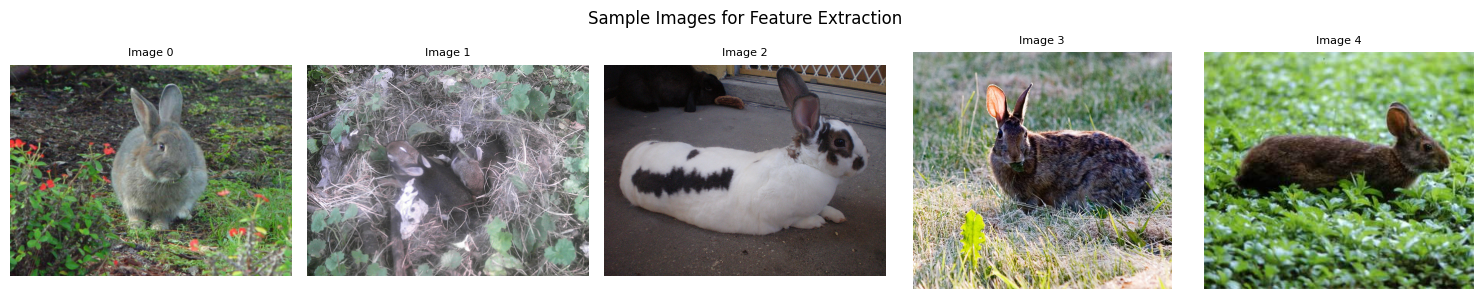

In [65]:
# Cell 3: Define Steering Concepts & Load Test Images
import glob

STEERING_CONCEPTS = ["scientific", "artistic", "medical", "poetic"]
BASE_PROMPT = "Describe the image."

# Load test images - try multiple sources
test_image_dirs = [
    "/mnt/abka03/xlvlm_data/oneclass/rabbit/",
    os.path.abspath(os.path.join(os.getcwd(), "..", "data", "train")),
]

image_paths = []
for d in test_image_dirs:
    if os.path.isdir(d):
        found = sorted(glob.glob(os.path.join(d, "**", "*.JPEG"), recursive=True))
        found += sorted(glob.glob(os.path.join(d, "**", "*.jpg"), recursive=True))
        found += sorted(glob.glob(os.path.join(d, "**", "*.png"), recursive=True))
        image_paths.extend(found)
    if len(image_paths) >= 10:
        break

image_paths = image_paths[:10]
images = [Image.open(p).convert("RGB") for p in image_paths]
test_image_path = "../data/val/bird/100489.jpg"
test_image = Image.open(test_image_path).convert("RGB")

print(f"Loaded {len(images)} images for feature extraction")
print(f"Test image: {image_paths[0]}")

# Show test image
fig, axes = plt.subplots(1, min(5, len(images)), figsize=(15, 3))
if not isinstance(axes, np.ndarray):
    axes = [axes]
for i, ax in enumerate(axes):
    ax.imshow(images[i])
    ax.set_title(f"Image {i}", fontsize=8)
    ax.axis("off")
plt.suptitle("Sample Images for Feature Extraction")
plt.tight_layout()
plt.show()

In [66]:
# Cell 4: Image Augmentation + Token-Specific Feature Extraction
from qwen_vl_utils import process_vision_info
import torchvision.transforms.v2 as T
import torchvision.transforms.functional as TF

# ===================== IMAGE AUGMENTATION =====================
def augment_images(images, num_augmentations=5, seed=42):
    """
    Create augmented versions of each image by varying brightness, contrast,
    hue, saturation, and adding Gaussian noise.
    Returns: list of (augmented_image, aug_label) for all images × augmentations.
    """
    rng = np.random.RandomState(seed)
    augmented = []

    for idx, img in enumerate(images):
        # Original
        augmented.append((img, f"img{idx}_original"))

        for a in range(num_augmentations):
            pil_img = img.copy()

            # Random brightness (0.5 to 1.5)
            brightness = rng.uniform(0.5, 1.5)
            pil_img = TF.adjust_brightness(pil_img, brightness)

            # Random contrast (0.5 to 1.5)
            contrast = rng.uniform(0.5, 1.5)
            pil_img = TF.adjust_contrast(pil_img, contrast)

            # Random hue shift (-0.15 to 0.15)
            hue = rng.uniform(-0.15, 0.15)
            pil_img = TF.adjust_hue(pil_img, hue)

            # Random saturation (0.3 to 1.7)
            saturation = rng.uniform(0.3, 1.7)
            pil_img = TF.adjust_saturation(pil_img, saturation)

            # Add Gaussian noise (50% chance)
            if rng.random() > 0.5:
                arr = np.array(pil_img).astype(np.float32)
                noise_std = rng.uniform(5, 25)
                noise = rng.normal(0, noise_std, arr.shape).astype(np.float32)
                arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
                pil_img = Image.fromarray(arr)

            augmented.append((pil_img, f"img{idx}_aug{a}_b{brightness:.2f}_c{contrast:.2f}_h{hue:.2f}"))

    return augmented

# ===================== HOOK & EXTRACTION =====================
# Global dict for hook states — stores (hidden_states, generated_token_ids) per call
HIDDEN_STATES = {}

def save_hidden_states_hook(module_name):
    """Forward hook that captures hidden states at the target layer."""
    def hook(module, input, output):
        if isinstance(output, tuple):
            out = output[0]
        else:
            out = output
        out = out.detach().cpu()
        if module_name in HIDDEN_STATES:
            HIDDEN_STATES[module_name].append(out)
        else:
            HIDDEN_STATES[module_name] = [out]
    return hook

def clear_hooks_and_states(handles):
    """Remove hooks and clear captured states."""
    global HIDDEN_STATES
    for h in handles:
        h.remove()
    HIDDEN_STATES.clear()

# Prompt templates (from src/models/constants.py)
PROMPT_TEMPLATES = {
    "cgdl": "Classify the input image as either: [concept], or No [concept]. Return only the predicted class label based on whether a [concept] is present in the image or not",
    "yn": "Does the image contain [concept]? Output only 'yes' or 'no'.",
    "dl": "Describe the image",
}

def build_prompt(concept, prompt_type="cgdl"):
    """Build prompt by replacing [concept] placeholder."""
    return PROMPT_TEMPLATES[prompt_type].replace("[concept]", concept)

def get_token_ids_for_word(processor, word):
    """Get all possible token IDs that encode (parts of) the steering word."""
    # Tokenize the word in various forms to handle subword tokenization
    variants = [word, word.lower(), word.capitalize(), word.upper(), f" {word}", f" {word.lower()}"]
    token_ids = set()
    for v in variants:
        ids = processor.tokenizer.encode(v, add_special_tokens=False)
        token_ids.update(ids)
    return token_ids

def extract_hidden_at_steering_tokens(hidden_states_list, generated_token_ids, steering_token_ids):
    """
    Extract hidden states ONLY at positions where the generated token matches a steering word token.
    
    Args:
        hidden_states_list: list of (1, num_tokens, D) tensors from autoregressive steps
        generated_token_ids: (seq_len,) tensor of generated token IDs
        steering_token_ids: set of token IDs for the steering concept word
    
    Returns:
        (D,) mean hidden state at steering token positions, or None if not found
    """
    if not hidden_states_list:
        return None

    # Each hook call captures hidden states for the tokens generated at that step
    # In autoregressive generation, each step generates 1 token but the hook sees all tokens
    # We need to match generated_token_ids to the last token of each hook output
    all_hidden = torch.cat(hidden_states_list, dim=1)  # (1, total_tokens, D)

    # generated_token_ids are the new tokens (after input_len)
    # Match positions where generated token is a steering word token
    matching_positions = []
    for pos, tid in enumerate(generated_token_ids.tolist()):
        if tid in steering_token_ids:
            matching_positions.append(pos)

    if not matching_positions:
        return None

    # The hook captures states for all sequence positions during prefill,
    # then 1 position per step during generation.
    # For autoregressive: hidden_states_list[0] has prefill states, rest have 1 token each.
    # The generated tokens map to hook outputs at index [1:] if first is prefill.
    # Simplest: concatenate all and take the last N positions where N = len(generated_token_ids)
    total_captured = all_hidden.shape[1]
    num_generated = len(generated_token_ids)
    
    # Generated tokens correspond to the LAST num_generated positions in the concatenated hidden states
    offset = total_captured - num_generated
    absolute_positions = [offset + p for p in matching_positions if offset + p < total_captured]
    
    if not absolute_positions:
        return None

    selected = all_hidden[0, absolute_positions, :]  # (num_matches, D)
    return selected.mean(dim=0).float()  # (D,)

def run_inference_and_capture(model, processor, image, prompt, steering_word=None,
                              hook_layer=HOOK_LAYER, max_new_tokens=50):
    """
    Run inference with a hook. If steering_word is given, extract hidden states
    ONLY at token positions matching the steering word. Otherwise, mean-pool all.
    """
    global HIDDEN_STATES
    HIDDEN_STATES.clear()

    target_module = dict(model.named_modules())[hook_layer]
    handle = target_module.register_forward_hook(save_hidden_states_hook(hook_layer))

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]}
    ]

    text = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt"
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)

    generated_ids = output[0][input_len:]  # only the new tokens
    decoded = processor.decode(generated_ids, skip_special_tokens=True)

    # Extract hidden states
    hidden_list = HIDDEN_STATES.get(hook_layer, None)
    h_mean = None

    if hidden_list and len(hidden_list) > 0:
        if steering_word is not None:
            # Token-specific extraction: only at steering word positions
            steering_token_ids = get_token_ids_for_word(processor, steering_word)
            h_mean = extract_hidden_at_steering_tokens(hidden_list, generated_ids.cpu(), steering_token_ids)
            # Fallback to mean-pool if steering word not found in output
            if h_mean is None:
                h = torch.cat(hidden_list, dim=1)
                h_mean = h.mean(dim=1).squeeze(0).float()
        else:
            # Mean-pool all generated token positions
            h = torch.cat(hidden_list, dim=1)
            h_mean = h.mean(dim=1).squeeze(0).float()

    handle.remove()
    HIDDEN_STATES.clear()
    return decoded, h_mean

def extract_concept_features(model, processor, images, concept, prompt_type="cgdl",
                              hook_layer=HOOK_LAYER, use_steering_token=True):
    """
    Extract hidden state features for a concept across images.
    If use_steering_token=True, only extract at positions where the model generates 
    tokens matching the concept word (more focused signal).
    """
    prompt = build_prompt(concept, prompt_type)
    steering_word = concept if use_steering_token else None
    features, responses = [], []
    steering_token_hits = 0

    for i, img in enumerate(images):
        img_input = img[0] if isinstance(img, tuple) else img
        decoded, h = run_inference_and_capture(
            model, processor, img_input, prompt,
            steering_word=steering_word, hook_layer=hook_layer
        )
        if h is not None:
            features.append(h)
            responses.append(decoded)
            # Check if the steering word actually appeared
            if steering_word and steering_word.lower() in decoded.lower():
                steering_token_hits += 1
        if (i + 1) % 10 == 0:
            print(f"  Processed {i+1}/{len(images)} images...")

    if use_steering_token:
        print(f"  Steering word '{concept}' found in {steering_token_hits}/{len(images)} outputs")

    if features:
        return torch.stack(features, dim=0), responses  # (N, D)
    return None, responses

print("Image augmentation + token-specific feature extraction functions defined.")

Image augmentation + token-specific feature extraction functions defined.


Original images: 10
Augmented set: 60 (5 augmentations + 1 original per image)


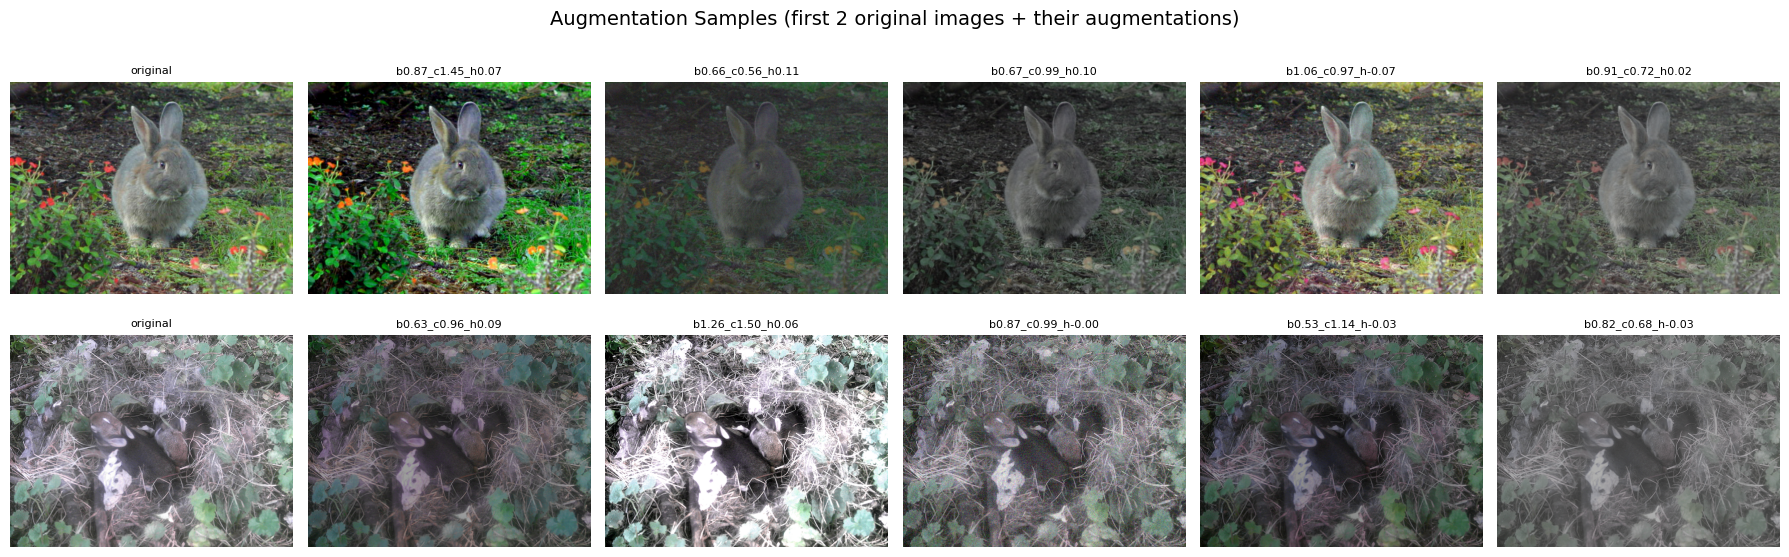


=== Extracting features for concept: 'fiction' ===
Using 60 augmented images
Mode: steering-token-specific extraction (only 'fiction' token positions)

--- CGDL prompt ---
Prompt: Classify the input image as either: fiction, or No fiction. Return only the pred...
  Processed 10/60 images...
  Processed 20/60 images...
  Processed 30/60 images...
  Processed 40/60 images...
  Processed 50/60 images...
  Processed 60/60 images...
  Steering word 'fiction' found in 60/60 outputs
CGDL features shape: torch.Size([60, 2048])
  Sample 0: 'No fiction'
  Sample 1: 'No fiction'
  Sample 2: 'No fiction'

--- YN prompt ---
Prompt: Does the image contain fiction? Output only 'yes' or 'no'....
  Processed 10/60 images...
  Processed 20/60 images...
  Processed 30/60 images...
  Processed 40/60 images...
  Processed 50/60 images...
  Processed 60/60 images...
  Steering word 'fiction' found in 0/60 outputs
YN features shape: torch.Size([60, 2048])
  Sample 0: 'no'
  Sample 1: 'no'
  Sample 2: 'no'



In [67]:
# Cell 5: Augment Images → Extract Steering-Token-Specific Features
steering_concept = "fiction"  # choose a concept that is likely to be mentioned in the description of the images

# --- Step 1: Augment images ---
NUM_AUGMENTATIONS = 5  # 5 augmentations per image → 10*(1+5) = 60 total samples
augmented_images = augment_images(images, num_augmentations=NUM_AUGMENTATIONS, seed=42)
print(f"Original images: {len(images)}")
print(f"Augmented set: {len(augmented_images)} ({NUM_AUGMENTATIONS} augmentations + 1 original per image)")

# Show a few augmented examples
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("Augmentation Samples (first 2 original images + their augmentations)", fontsize=14)
for row in range(2):
    base_idx = row * (NUM_AUGMENTATIONS + 1)
    for col in range(min(6, NUM_AUGMENTATIONS + 1)):
        img_item = augmented_images[base_idx + col]
        axes[row, col].imshow(img_item[0])
        axes[row, col].set_title(img_item[1].split("_", 2)[-1][:20], fontsize=8)
        axes[row, col].axis("off")
plt.tight_layout()
plt.show()

# --- Step 2: Extract features with steering-token-specific extraction ---
print(f"\n=== Extracting features for concept: '{steering_concept}' ===")
print(f"Using {len(augmented_images)} augmented images")
print(f"Mode: steering-token-specific extraction (only '{steering_concept}' token positions)\n")

# Extract with CGDL prompt
print("--- CGDL prompt ---")
print(f"Prompt: {build_prompt(steering_concept, 'cgdl')[:80]}...")
features_cgdl, responses_cgdl = extract_concept_features(
    model, processor, augmented_images, steering_concept,
    prompt_type="cgdl", use_steering_token=True
)
print(f"CGDL features shape: {features_cgdl.shape}")
for i, r in enumerate(responses_cgdl[:3]):
    print(f"  Sample {i}: '{r}'")

# Extract with YN prompt
print("\n--- YN prompt ---")
print(f"Prompt: {build_prompt(steering_concept, 'yn')[:80]}...")
features_yn, responses_yn = extract_concept_features(
    model, processor, augmented_images, steering_concept,
    prompt_type="yn", use_steering_token=True
)
print(f"YN features shape: {features_yn.shape}")
for i, r in enumerate(responses_yn[:3]):
    print(f"  Sample {i}: '{r}'")

# Extract baseline (no steering-token extraction — describe is not concept-aware)
print("\n--- Baseline (describe image) ---")
print(f"Prompt: {build_prompt(steering_concept, 'dl')[:80]}...")
features_baseline, responses_baseline = extract_concept_features(
    model, processor, augmented_images, steering_concept,
    prompt_type="dl", use_steering_token=False  # baseline uses mean-pool
)
print(f"Baseline features shape: {features_baseline.shape}")
for i, r in enumerate(responses_baseline[:3]):
    print(f"  Sample {i}: '{r[:60]}...'")

In [68]:
# Cell 6: SNMF Decomposition
from sklearn.decomposition import DictionaryLearning

def decompose_snmf(features, num_concepts=5, seed=42):
    """
    Semi-Non-negative Matrix Factorization via DictionaryLearning.
    Mirrors decompose_activations() from src/analysis/feature_decomposition.py with method='snmf'.
    
    Args:
        features: (N, D) tensor of hidden state features
        num_concepts: number of concept components K
    Returns:
        concepts: (K, D) tensor — the learned concept directions
        activations: (N, K) tensor — how each sample activates each concept
    """
    mat = features.numpy().astype(np.float64)
    dl = DictionaryLearning(
        n_components=num_concepts,
        alpha=1.0,
        max_iter=500,
        fit_algorithm="cd",
        transform_algorithm="lasso_cd",
        positive_code=True,
        random_state=seed,
    )
    activations = dl.fit_transform(mat)   # (N, K)
    concepts = dl.components_             # (K, D)
    return torch.tensor(concepts, dtype=torch.float32), torch.tensor(activations, dtype=torch.float32), dl

NUM_CONCEPTS = 2

# Decompose CGDL features
print(f"SNMF decomposition (K={NUM_CONCEPTS})...")
print("  CGDL features...")
concepts_cgdl, activations_cgdl, dl_cgdl = decompose_snmf(features_cgdl, num_concepts=NUM_CONCEPTS)
print(f"  -> Concepts: {concepts_cgdl.shape}, Activations: {activations_cgdl.shape}")

# Decompose YN features
print("  YN features...")
concepts_yn, activations_yn, dl_yn = decompose_snmf(features_yn, num_concepts=NUM_CONCEPTS)
print(f"  -> Concepts: {concepts_yn.shape}, Activations: {activations_yn.shape}")

# Decompose baseline features
print("  Baseline features...")
concepts_baseline, activations_baseline, dl_baseline = decompose_snmf(features_baseline, num_concepts=NUM_CONCEPTS)
print(f"  -> Concepts: {concepts_baseline.shape}, Activations: {activations_baseline.shape}")
print("\nDone.")

SNMF decomposition (K=2)...
  CGDL features...
  -> Concepts: torch.Size([2, 2048]), Activations: torch.Size([60, 2])
  YN features...
  -> Concepts: torch.Size([2, 2048]), Activations: torch.Size([60, 2])
  Baseline features...
  -> Concepts: torch.Size([2, 2048]), Activations: torch.Size([60, 2])

Done.


In [69]:
# Cell 7: Compute Steering Vectors
# Two methods from src/analysis/model_steering.py:
# 1. Shift-of-means: direction from baseline to concept-specific representations
# 2. Intra-cluster: differences between SNMF concept vectors

def compute_steering_vector_shift_of_means(features_concept, features_baseline):
    """Steering vector = mean(concept_features) - mean(baseline_features)."""
    return features_concept.mean(0) - features_baseline.mean(0)

def compute_steering_vectors_intra_cluster(concepts):
    """All pairwise difference vectors between SNMF concept components."""
    vectors = {}
    for i in range(concepts.shape[0]):
        for j in range(concepts.shape[0]):
            if i != j:
                vectors[f"concept_{i}_to_{j}"] = concepts[i] - concepts[j]
    return vectors

# ---- Method 1: Shift-of-Means ----
steering_vec_cgdl = compute_steering_vector_shift_of_means(features_cgdl, features_baseline)
steering_vec_yn = compute_steering_vector_shift_of_means(features_yn, features_baseline)

print("=== Steering Vectors (Shift-of-Means) ===")
print(f"CGDL: norm={steering_vec_cgdl.norm():.4f}, mean={steering_vec_cgdl.mean():.6f}")
print(f"YN:   norm={steering_vec_yn.norm():.4f}, mean={steering_vec_yn.mean():.6f}")

# Compare CGDL vs YN vectors
cos_sim_cgdl_yn = F.cosine_similarity(steering_vec_cgdl.unsqueeze(0), steering_vec_yn.unsqueeze(0)).item()
print(f"\nCosine similarity (CGDL vs YN): {cos_sim_cgdl_yn:.4f}")

# ---- Method 2: Intra-Cluster (SNMF concepts) ----
intra_vectors = compute_steering_vectors_intra_cluster(concepts_cgdl)
print(f"\nIntra-cluster vectors: {len(intra_vectors)} pairs")

# Find best aligned with shift-of-means
best_key, best_sim = None, -1
for k, v in intra_vectors.items():
    sim = F.cosine_similarity(v.unsqueeze(0), steering_vec_cgdl.unsqueeze(0)).item()
    if sim > best_sim:
        best_sim = sim
        best_key = k
print(f"Best intra-cluster vector: {best_key} (cos_sim={best_sim:.4f})")

# Primary steering vector: use CGDL shift-of-means
steering_vec = steering_vec_cgdl.clone()
print(f"\n>>> PRIMARY steering vector: CGDL shift-of-means, norm={steering_vec.norm():.4f}")

=== Steering Vectors (Shift-of-Means) ===
CGDL: norm=165.1170, mean=-0.123971
YN:   norm=20.1313, mean=0.007969

Cosine similarity (CGDL vs YN): 0.2615

Intra-cluster vectors: 2 pairs
Best intra-cluster vector: concept_0_to_1 (cos_sim=0.1130)

>>> PRIMARY steering vector: CGDL shift-of-means, norm=165.1170


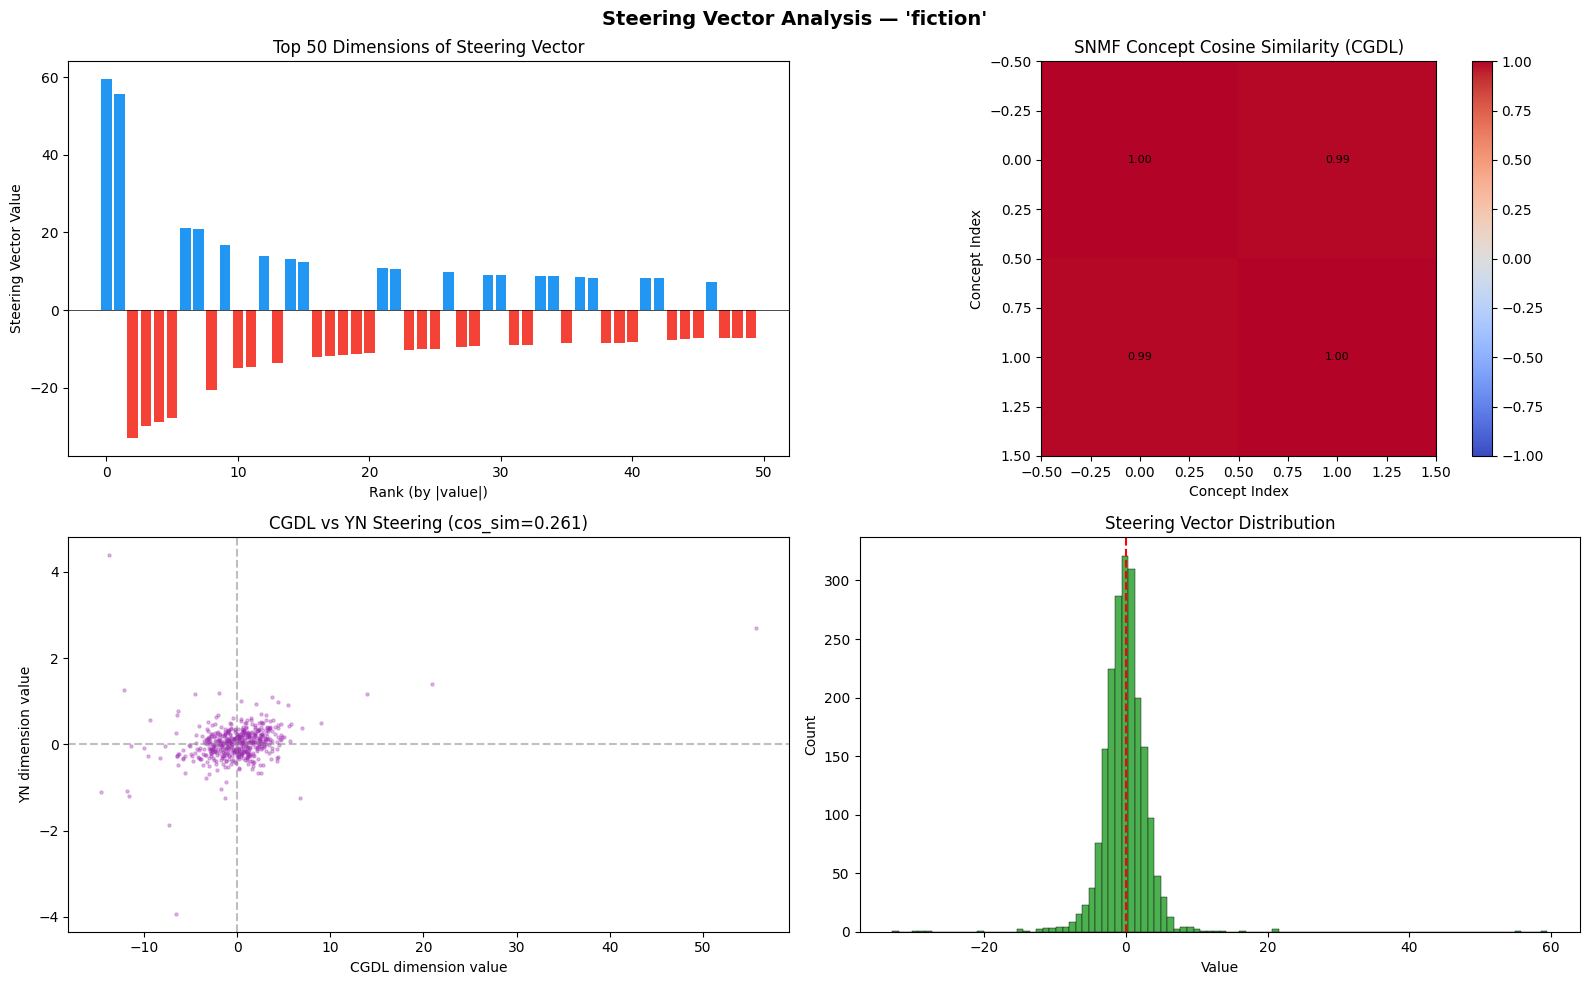

In [70]:
# Cell 8: Visualization — Steering Vector Analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Top dimensions of steering vector by magnitude
ax = axes[0, 0]
topk = 50
abs_vals = steering_vec.abs()
top_idx = abs_vals.topk(topk).indices.numpy()
top_vals = steering_vec[top_idx].numpy()
colors = ['#2196F3' if v > 0 else '#F44336' for v in top_vals]
ax.bar(range(topk), top_vals, color=colors)
ax.set_xlabel("Rank (by |value|)")
ax.set_ylabel("Steering Vector Value")
ax.set_title(f"Top {topk} Dimensions of Steering Vector")
ax.axhline(0, color='black', linewidth=0.5)

# 2. Cosine similarity heatmap between SNMF concepts
ax = axes[0, 1]
concepts_norm = F.normalize(concepts_cgdl, dim=1)
sim_matrix = (concepts_norm @ concepts_norm.T).numpy()
im = ax.imshow(sim_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title("SNMF Concept Cosine Similarity (CGDL)")
ax.set_xlabel("Concept Index")
ax.set_ylabel("Concept Index")
for i in range(sim_matrix.shape[0]):
    for j in range(sim_matrix.shape[1]):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)

# 3. CGDL vs YN scatter
ax = axes[1, 0]
n_show = min(500, steering_vec_cgdl.shape[0])
ax.scatter(steering_vec_cgdl.numpy()[:n_show], steering_vec_yn.numpy()[:n_show], alpha=0.3, s=5, c='#9C27B0')
ax.set_xlabel("CGDL dimension value")
ax.set_ylabel("YN dimension value")
ax.set_title(f"CGDL vs YN Steering (cos_sim={cos_sim_cgdl_yn:.3f})")
ax.axhline(0, color='gray', ls='--', alpha=0.5)
ax.axvline(0, color='gray', ls='--', alpha=0.5)

# 4. Value distribution
ax = axes[1, 1]
ax.hist(steering_vec.numpy(), bins=100, color='#4CAF50', edgecolor='black', linewidth=0.3)
ax.set_xlabel("Value")
ax.set_ylabel("Count")
ax.set_title("Steering Vector Distribution")
ax.axvline(0, color='red', ls='--')

plt.suptitle(f"Steering Vector Analysis — '{steering_concept}'", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
# Cell 9: Steering Inference Functions & Baseline

def apply_steering_vector_fn(x, vector, alpha=1.0):
    """Add scaled steering vector to hidden states (mirrors src/helpers/utils.py:apply_steering_vector)."""
    return x + alpha * vector.to(x.device).to(x.dtype)

def run_steered_inference(model, processor, image, prompt, steering_vector=None, alpha=1.0,
                          hook_layer=HOOK_LAYER, max_new_tokens=200):
    """Run inference with optional steering hook on the target layer."""
    handles = []

    if steering_vector is not None and alpha != 0:
        target_module = dict(model.named_modules())[hook_layer]
        def steering_hook(module, input, output):
            if isinstance(output, tuple):
                steered = apply_steering_vector_fn(output[0], steering_vector, alpha=alpha)
                return (steered,) + output[1:]
            else:
                return apply_steering_vector_fn(output, steering_vector, alpha=alpha)
        handles.append(target_module.register_forward_hook(steering_hook))

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt}
        ]}
    ]

    text = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text], images=image_inputs, videos=video_inputs,
        padding=True, return_tensors="pt"
    ).to(model.device)

    input_len = inputs["input_ids"].shape[-1]
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    decoded = processor.decode(output[0][input_len:], skip_special_tokens=True)

    for h in handles:
        h.remove()
    return decoded

# Run baseline (no steering)
print("=== BASELINE (No Steering) ===")
print(f"Prompt: '{BASE_PROMPT}'\n")
baseline_output = run_steered_inference(model, processor, test_image, BASE_PROMPT, steering_vector=None)
print(baseline_output)

=== BASELINE (No Steering) ===
Prompt: 'Describe the image.'



The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some yellow leaves, indicating that it might be autumn. The overall scene is serene and natural.


In [72]:
# Cell 10: Steered Inference — Before/After Comparison
# α=0.5 is the sweet spot: visible steering effect without repetition/collapse
alpha = 0.5

steered_output = run_steered_inference(
    model, processor, test_image, BASE_PROMPT,
    steering_vector=steering_vec, alpha=alpha
)

print("=" * 70)
print(f"Steering concept: '{steering_concept}' | Alpha: {alpha}")
print(f"Steering vector norm: {steering_vec.norm():.2f} | Effective perturbation: {(steering_vec * alpha).norm():.2f}")
print("=" * 70)
print(f"\n--- BASELINE (no steering) ---\n{baseline_output}")
print(f"\n--- STEERED (alpha={alpha}) ---\n{steered_output}")
print("=" * 70)

# Side-by-side HTML display
display(HTML(f"""
<table style="width:100%; border-collapse:collapse; border:1px solid #ccc;">
<tr>
    <th style="text-align:left; padding:10px; background:#f5f5f5; width:50%;">Baseline (No Steering)</th>
    <th style="text-align:left; padding:10px; background:#e8f5e9; width:50%;">Steered → '{steering_concept}' (α={alpha})</th>
</tr>
<tr>
    <td style="padding:10px; vertical-align:top; border:1px solid #eee;">{baseline_output}</td>
    <td style="padding:10px; vertical-align:top; border:1px solid #eee;">{steered_output}</td>
</tr>
</table>
"""))

Steering concept: 'fiction' | Alpha: 0.5
Steering vector norm: 165.12 | Effective perturbation: 82.56

--- BASELINE (no steering) ---
The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some yellow leaves, indicating that it might be autumn. The overall scene is serene and natural.

--- STEERED (alpha=0.5) ---
The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with a hint of red on its chest. It is set against a clear, blue sky. The branch it is perched on has some autumn-foliage leaves, indicating that the photo was likely taken in fall.


Baseline (No Steering),Steered → 'fiction' (α=0.5)
"The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some yellow leaves, indicating that it might be autumn. The overall scene is serene and natural.","The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with a hint of red on its chest. It is set against a clear, blue sky. The branch it is perched on has some autumn-foliage leaves, indicating that the photo was likely taken in fall."


In [73]:
# Cell 11: Alpha Sweep — How steering strength affects output
# Vec norm is ~156 now (token-specific extraction), so scale alphas down ~6x from before
alpha_values = [0, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
sweep_results = []

print(f"Alpha sweep for concept: '{steering_concept}' (vec norm={steering_vec.norm():.2f})")
print("-" * 80)

for alpha_val in alpha_values:
    out = run_steered_inference(
        model, processor, test_image, BASE_PROMPT,
        steering_vector=steering_vec, alpha=alpha_val
    )
    sweep_results.append({"alpha": alpha_val, "output": out})
    eff_norm = alpha_val * steering_vec.norm().item()
    truncated = out[:120].replace("\n", " ")
    print(f"α={alpha_val:>5.2f} | eff_norm={eff_norm:>7.1f} | {truncated}...")

# HTML table
rows_html = ""
for r in sweep_results:
    bg = "#e8f5e9" if r["alpha"] > 0 else "#f5f5f5"
    rows_html += f'<tr style="background:{bg};"><td style="padding:8px; font-weight:bold;">{r["alpha"]:.2f}</td><td style="padding:8px;">{r["output"]}</td></tr>'

display(HTML(f"""
<h3>Alpha Sweep — '{steering_concept}' (vec norm={steering_vec.norm():.1f})</h3>
<table style="border-collapse:collapse; width:100%;">
<tr><th style="padding:8px; text-align:left; background:#333; color:white;">Alpha</th><th style="padding:8px; text-align:left; background:#333; color:white;">Output</th></tr>
{rows_html}
</table>
"""))

Alpha sweep for concept: 'fiction' (vec norm=165.12)
--------------------------------------------------------------------------------


α= 0.00 | eff_norm=    0.0 | The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its...
α= 0.01 | eff_norm=    1.7 | The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its...
α= 0.05 | eff_norm=    8.3 | The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its...
α= 0.10 | eff_norm=   16.5 | The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its...
α= 0.20 | eff_norm=   33.0 | The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with its wings and tail feathers bei...
α= 0.30 | eff_norm=   49.5 | The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with a distinctive blue tail. The ba...
α= 0.50 | eff_norm=   82.6 | The image depicts a bird perched on a branch. The bir

Alpha,Output
0.00,"The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some yellow leaves, indicating that it might be autumn. The overall scene is serene and natural."
0.01,"The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some yellow leaves, indicating that it might be autumn. The overall scene is serene and natural."
0.05,"The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some autumn leaves that are turning yellow and orange. The overall scene suggests a serene, natural setting."
0.10,"The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear, bright blue sky, suggesting it might be taken during daytime. The tree branches have some autumn leaves, which are yellow and orange, indicating that the season is fall. The overall scene is serene and natural."
0.20,"The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with its wings and tail feathers being particularly vibrant blue. The background is a clear, bright blue sky, suggesting it might be taken during daytime. The bird appears to be in a natural setting, possibly a forest or a wooded area, as there are some green and yellow leaves visible in the foreground. The overall scene gives a sense of tranquility and natural beauty."
0.30,"The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with a distinctive blue tail. The background is a clear blue sky, and there are some autumn leaves in the foreground, indicating that the photo was likely taken during fall. The overall scene is serene, with the bird as the focal point."
0.50,"The image depicts a bird perched on a branch. The bird has a blue and gray plumage, with a hint of red on its chest. It is set against a clear, blue sky. The branch it is perched on has some autumn-foliage leaves, indicating that the photo was likely taken in fall."
0.75,"The image depicts a bird perched on a branch. The bird has a blue-frosted appearance, with a combination of blue, black, and white feathers. It is set against a clear, blue sky. The branch it is perched on has some autumn-foliage, featuring a mix of green, yellow, and red leaves."
1.00,fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction fiction 

In [74]:
# Cell 12: Multiple Concepts Comparison (with augmentation + token-specific extraction)
# Lower alpha since token-specific extraction produces higher-norm vectors
ALPHA_MULTI = 0.5
multi_concept_results = {}

print(f"=== Multi-Concept Steering (α={ALPHA_MULTI}) ===")
print(f"Using {len(augmented_images)} augmented images, token-specific extraction\n")

for concept in STEERING_CONCEPTS:
    print(f"Processing concept: '{concept}'...")
    
    # Extract concept features (CGDL) with augmented images + token-specific extraction
    feats_c, resp_c = extract_concept_features(
        model, processor, augmented_images, concept,
        prompt_type="cgdl", use_steering_token=True
    )
    # Extract baseline features (describe) — no token-specific for baseline
    feats_b, resp_b = extract_concept_features(
        model, processor, augmented_images, concept,
        prompt_type="dl", use_steering_token=False
    )

    if feats_c is not None and feats_b is not None:
        sv = feats_c.mean(0) - feats_b.mean(0)  # shift-of-means
        out = run_steered_inference(
            model, processor, test_image, BASE_PROMPT,
            steering_vector=sv, alpha=ALPHA_MULTI
        )
        multi_concept_results[concept] = {
            "output": out if out.strip() else "(collapsed)",
            "vec_norm": sv.norm().item(),
            "steering_vector": sv,
        }
        print(f"  Done. vec_norm={sv.norm():.3f}")
        print(f"  Output: {out[:100]}...\n")
    else:
        print(f"  FAILED to extract features.\n")

# Summary table
print("=" * 80)
print(f"{'Concept':<15} {'Vec Norm':<12} {'Output (first 100 chars)'}")
print("-" * 80)
print(f"{'(baseline)':<15} {'N/A':<12} {baseline_output[:100]}")
for concept, data in multi_concept_results.items():
    print(f"{concept:<15} {data['vec_norm']:<12.3f} {data['output'][:100]}")

# HTML comparison
rows = f'<tr style="background:#f5f5f5"><td style="padding:8px; font-weight:bold;">(baseline)</td><td style="padding:8px;">N/A</td><td style="padding:8px;">{baseline_output}</td></tr>'
for concept, data in multi_concept_results.items():
    rows += f'<tr><td style="padding:8px; font-weight:bold;">{concept}</td><td style="padding:8px;">{data["vec_norm"]:.2f}</td><td style="padding:8px;">{data["output"]}</td></tr>'

display(HTML(f"""
<h3>Multi-Concept Steering Comparison (α={ALPHA_MULTI})</h3>
<table style="width:100%; border-collapse:collapse; border:1px solid #ccc;">
<tr><th style="padding:8px; background:#eee;">Concept</th><th style="padding:8px; background:#eee;">Vec Norm</th><th style="padding:8px; background:#eee;">Generated Output</th></tr>
{rows}
</table>
"""))

=== Multi-Concept Steering (α=0.5) ===
Using 60 augmented images, token-specific extraction

Processing concept: 'scientific'...
  Processed 10/60 images...
  Processed 20/60 images...
  Processed 30/60 images...
  Processed 40/60 images...
  Processed 50/60 images...
  Processed 60/60 images...
  Steering word 'scientific' found in 60/60 outputs
  Processed 10/60 images...
  Processed 20/60 images...
  Processed 30/60 images...
  Processed 40/60 images...
  Processed 50/60 images...
  Processed 60/60 images...
  Done. vec_norm=156.004
  Output: The image depicts a bird perched on a branch. The bird has a vibrant blue and white plumage, with it...

Processing concept: 'artistic'...
  Processed 10/60 images...
  Processed 20/60 images...
  Processed 30/60 images...
  Processed 40/60 images...
  Processed 50/60 images...
  Processed 60/60 images...
  Steering word 'artistic' found in 60/60 outputs
  Processed 10/60 images...
  Processed 20/60 images...
  Processed 30/60 images...
  Proce

Concept,Vec Norm,Generated Output
(baseline),N/A,"The image depicts a bird perched on a branch of a tree. The bird has a blue and gray plumage with a hint of white on its chest. The background is a clear blue sky, and the tree branches have some yellow leaves, indicating that it might be autumn. The overall scene is serene and natural."
scientific,156.00,"The image depicts a bird perched on a branch. The bird has a vibrant blue and white plumage, with its wings and tail showcasing striking blue hues. The background is a clear, bright blue sky, suggesting it might be a sunny day. The branch the bird is standing on is adorned with some autumnal leaves, indicating that the season is likely fall."
artistic,156.72,"The image depicts a bird perched on a branch. The bird has a vibrant blue and gray plumage, with distinctive markings. It is set against a clear, bright blue sky. The background includes some autumnal foliage, featuring vibrant orange and yellow leaves."
medical,162.63,"The image depicts a bird perched on a branch. The bird has a metallic blue body with hints of iridescent green, and its tail feathers are long and blue. The background is a clear, bright blue sky."
poetic,164.87,"The image depicts a bird perched on a branch. The bird has a vibrant blue body, with hints of green and brown, particularly noticeable in its wings. It is set against a clear, bright blue sky. The branch it's perched on has some autumnal leaves, which are a mix of green, yellow, and orange. The overall scene suggests a serene, natural setting."


In [75]:
# Cell 13: Cleanup
# Remove any lingering hooks
for name, module in model.named_modules():
    module._forward_hooks.clear()

torch.cuda.empty_cache()
print("All hooks removed, GPU cache cleared.")

All hooks removed, GPU cache cleared.
